In [2]:
import numpy as np
import glob, os, sys
import copy
import xarray as xr
import pandas as pd
from scipy import ndimage
from scipy.ndimage import label, binary_dilation, binary_erosion, generate_binary_structure
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
# For non-gui matplotlib back end
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
mpl.use('agg')
import dask
from dask.distributed import Client, LocalCluster
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
# from pyflextrkr.ft_utilities import load_config, subset_files_timerange

In [3]:
pixeltracking_path = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204_gefs_en18/500m/celltracking/20181204.1200_20181205.0000/'
pixeltracking_filebase = "celltracks_"
regrid_path = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/20181204/gefs18/d3/run/'
regrid_filebase = 'corlasso_sub_metOnHamsl.M1.m1.gefs18_'
# map_file = '/gpfs/wolf/cli120/proj-shared/zfeng/cacti/les/map_data/corlasso_sub_static.M1.m1.gefs18_2018120400_f120000_d3.nc'

In [4]:
start_datetime = '2018-12-04T20:00'
end_datetime = '2018-12-04T20:05'

# Generate time marks within the start/end datetime
file_datetimes = pd.date_range(start=start_datetime, end=end_datetime, freq='15min').strftime('%Y%m%d_%H%M')
met_datetimes = pd.date_range(start=start_datetime, end=end_datetime, freq='15min').strftime('%Y%m%d00_f%H%M')

datafiles = []
metfiles = []
for tt in range(0, len(file_datetimes)):
    datafiles.extend(sorted(glob.glob(f'{pixeltracking_path}{pixeltracking_filebase}{file_datetimes[tt]}*')))
    metfiles.extend(sorted(glob.glob(f'{regrid_path}{regrid_filebase}{met_datetimes[tt]}*')))
print(f'Number of pixel files: {len(datafiles)}')
print(f'Number of met files: {len(metfiles)}')

Number of pixel files: 1
Number of met files: 1


In [5]:
datafile = datafiles[0]
metfile = metfiles[0]

# Read Met file
dsm = xr.open_dataset(metfile)
# Rename dimenensions
dsm = dsm.rename_dims({'south_north':'lat', 'west_east':'lon'})
nz = dsm.dims['HAMSL']
height = dsm['HAMSL'].data
DX = dsm.attrs['DX']
DY = dsm.attrs['DY']
grid_area = DX * DY / 1e6

# Read cell track file
ds = xr.open_dataset(datafile)
# Drop 1D lat/lon coordinates, and reasign 2D XLONG/XLAT coordinates from Met file
# It does not seem like this is necessary in Xarray 0.21.1
ds = ds.drop_vars(['lon', 'lat']).assign_coords({'XLONG':dsm['XLONG'], 'XLAT':dsm['XLAT']})
# Make x,y coordinates
# ds.coords['lon'] = ds.lon
# ds.coords['lat'] = ds.lat
# xx = ds.lon.data
# yy = ds.lat.data
# longitude = ds.longitude.data
# latitude = ds.latitude.data
tracknumber = ds.tracknumber.squeeze()
ds

<xarray.Dataset>
Dimensions:            (time: 1, lat: 865, lon: 750)
Coordinates:
  * time               (time) datetime64[ns] 2018-12-04T20:00:00
    XLAT               (lat, lon) float32 -33.97 -33.97 -33.97 ... -30.03 -30.03
    XLONG              (lat, lon) float32 -66.28 -66.28 -66.27 ... -62.31 -62.3
Dimensions without coordinates: lat, lon
Data variables: (12/19)
    base_time          (time) datetime64[ns] ...
    longitude          (lat, lon) float32 ...
    latitude           (lat, lon) float32 ...
    nclouds            (time) int64 ...
    comp_ref           (time, lat, lon) float32 ...
    dbz_lowlevel       (time, lat, lon) float32 ...
    ...                 ...
    split_tracknumber  (time, lat, lon) float64 ...
    echotop10          (time, lat, lon) float32 ...
    echotop20          (time, lat, lon) float32 ...
    echotop30          (time, lat, lon) float32 ...
    echotop40          (time, lat, lon) float32 ...
    echotop50          (time, lat, lon) float32 ...
Attributes:
    title:       Pixel-level cell tracking data
    contact:     Zhe Feng, zhe.feng@pnnl.gov
    created_on:  Thu May  5 20:13:50 2022

In [6]:
dsm['HAMSL']

<xarray.DataArray 'HAMSL' (HAMSL: 29)>
array([  500.,  1000.,  1500.,  2000.,  2500.,  3000.,  3500.,  4000.,  4500.,
        5000.,  5500.,  6000.,  6500.,  7000.,  7500.,  8000.,  9000., 10000.,
       11000., 12000., 13000., 14000., 15000., 16000., 17000., 18000., 19000.,
       20000., 21000.])
Coordinates:
  * HAMSL    (HAMSL) float64 500.0 1e+03 1.5e+03 2e+03 ... 1.9e+04 2e+04 2.1e+04
Attributes:
    description:  model height - [MSL] (mass grid)
    units:        m
    stagger:

In [7]:
tracknumber

<xarray.DataArray 'tracknumber' (lat: 865, lon: 750)>
[648750 values with dtype=float64]
Coordinates:
    time     datetime64[ns] 2018-12-04T20:00:00
    XLAT     (lat, lon) float32 -33.97 -33.97 -33.97 ... -30.03 -30.03 -30.03
    XLONG    (lat, lon) float32 -66.28 -66.28 -66.27 ... -62.31 -62.31 -62.3
Dimensions without coordinates: lat, lon
Attributes:
    long_name:  Track number in this file at a given pixel
    units:      unitless

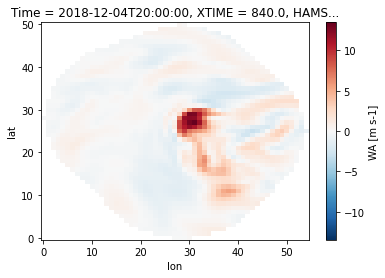

In [8]:
# tn = 23
tn = 175

# dsm.WA.where(tracknumber == 23, drop=True).sel(HAMSL=8000).squeeze().plot()
dsm.WA.where(tracknumber == tn, drop=True).sel(HAMSL=8000).squeeze().plot()

In [9]:
# Apply a Gaussian smoothing to W in the horizontal dimension
iW = dsm.WA.where(tracknumber == tn, drop=True).squeeze()
# iWs = ndimage.gaussian_filter(iW, sigma=[0,1,1], mode='nearest')

# Label 3D contiguous area with W > threshold as updraft "cores"
W_up_thresh = 2.0  # [m/s]
# iW_cores, ncores = ndimage.label((iWs > W_up_thresh))
iW_cores, ncores = ndimage.label((iW > W_up_thresh))

In [10]:
iW_np = dsm.WA.where(tracknumber == tn, drop=True).squeeze().data

# iW_cores = np.full(iW.shape, 0, dtype=int)
# ncores = np.full(nz, 0, dtype=int)
# for z in range(0, nz):
#     iW_cores[z,:,:], ncores[z] = ndimage.label((iW_np[z,:,:] > W_up_thresh))
    
#     core_numbers, npix_core = np.unique(iW_cores[z,:,:], return_counts=True)

In [11]:
def label_cores(W, W_thresh, ncores_min, min_core_npix, method='>'):
    # Label cores at a given vertical level
    if method == '>':
        core_label, ncores = ndimage.label((W > W_thresh))
    elif method == '<':
        core_label, ncores = ndimage.label((W < W_thresh))
    else:
        print(f'Error: Undefined method to label cores: {method}!')
    
    # Get core sizes
    core_numbers, npix_core = np.unique(core_label, return_counts=True)
    
    # Remove 0 label result since that is the background
    npix_core = npix_core[core_numbers > 0]
    core_numbers = core_numbers[core_numbers > 0]
    
    # Remove small cores
    mask = npix_core > min_core_npix
    npix_core = npix_core[mask]
    core_numbers = core_numbers[mask]

    # Sort the core size by descending order
    sort_idx = npix_core.argsort()[::-1]
    npix_core_sorted = npix_core[sort_idx]
    core_numbers_sorted = core_numbers[sort_idx]
    
    # Save the largest X cores
    ncores_save = np.nanmin([len(npix_core), ncores_min])
    
    return (ncores_save, npix_core_sorted[:ncores_save+1], core_numbers_sorted[:ncores_save+1], core_label)

In [12]:
W_up_thresh = 2.0  # [m/s]
W_down_thresh = -1.0  # [m/s]
min_core_npix = 4
ncores_min = 10

# tn = 175
z = 15
iW = dsm['WA'].where(tracknumber == tn, drop=True).squeeze().data
zW = iW[z,:,:]

ncores, core_npix, core_numbers, core_label = label_cores(zW, W_up_thresh, ncores_min, min_core_npix, method='>')
# ncores, core_npix, core_numbers, core_label = label_cores(iW[z,:,:], W_down_thresh, ncores_min, min_core_npix, method='<')
ncores, core_npix, core_numbers

(4, array([125,   8,   6,   6]), array([1, 4, 6, 3], dtype=int32))

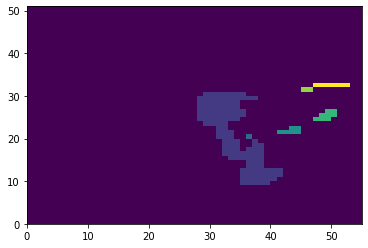

In [13]:
plt.pcolormesh(core_label)

In [14]:
# Calculate moist air density using virtual temperature
R_dry = 287.058   # J kg−1 K−1
Rho = 100 * dsm['PRESSURE'] / (R_dry * dsm['TV'])

# Calculate mass flux
MassFlux = (Rho * dsm['WA']).squeeze()

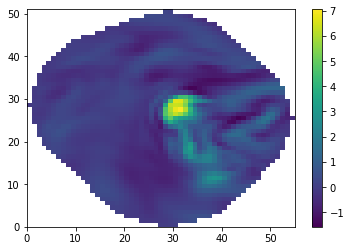

In [15]:
# min/max W, minmax mass flux, total mass flux, core area, core area > 3, 5, 10
# iRho = 1/dsm['ALT'].where(tracknumber == tn, drop=True).squeeze().data


# iRho = Rho.where(tracknumber == tn, drop=True).squeeze().data

# zRho = iRho[z,:,:]
# zW = iW[z,:,:]

# # Calculate mass flux
# zMassFlux = zRho * zW

zMassFlux = MassFlux.where(tracknumber == tn, drop=True).data[z,:,:]
plt.pcolormesh(zMassFlux)
plt.colorbar()

In [16]:
MassFlux_sum = np.full(ncores, np.NaN, dtype=np.float32)
for ii in range(ncores):
    # print(ii)
    MassFlux_sum[ii] = np.nansum(zMassFlux[core_label == core_numbers[ii]])
MassFlux_sum

array([330.73755  ,  11.420973 ,   6.9937315,   7.594891 ], dtype=float32)

In [17]:
iW = dsm['WA'].where(tracknumber == tn, drop=True).squeeze().data
iMassFlux = MassFlux.where(tracknumber == tn, drop=True).data

cell_MassFlux_up = np.full((nz, ncores_min), np.NaN, dtype=np.float32)
cell_CoreArea_up = np.full((nz, ncores_min), np.NaN, dtype=np.float32)
cell_CoreMaxW_up = np.full((nz, ncores_min), np.NaN, dtype=np.float32)
cell_nCore_up = np.full(nz, np.NaN, dtype=np.float32)

for z in range(0, nz):
    # print(height[z])
    zW = iW[z,:,:]
    zMassFlux = iMassFlux[z,:,:]

    # Label cores by thresholds
    ncores_up, core_npix_up, core_numbers_up, core_label_up = label_cores(zW, W_up_thresh, ncores_min, min_core_npix, method='>')
    # # ncores, core_npix, core_numbers, core_label = label_cores(iW[z,:,:], W_down_thresh, ncores_min, min_core_npix, method='<')
    cell_nCore_up[z] = ncores_up
    
    # Calculate core statistics
    MaFlx_sum_up = np.full(ncores_up, np.NaN, dtype=np.float32)
    W_max_up = np.full(ncores_up, np.NaN, dtype=np.float32)
    for ii in range(ncores_up):
        # print(ii)
        MaFlx_sum_up[ii] = np.nansum(zMassFlux[core_label_up == core_numbers_up[ii]])
        W_max_up[ii] = np.nanmax(zW[core_label_up == core_numbers_up[ii]])
    
    # Save the 
    ncores_save_up = min([ncores_up, ncores_min])
    cell_MassFlux_up[z, 0:ncores_save_up] = MaFlx_sum_up[0:ncores_save_up]
    cell_CoreArea_up[z, 0:ncores_save_up] = core_npix_up[0:ncores_save_up] * grid_area
    cell_CoreMaxW_up[z, 0:ncores_save_up] = W_max_up[0:ncores_save_up]

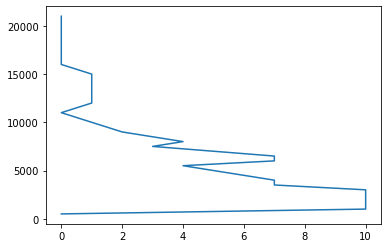

In [18]:
plt.plot(cell_nCore_up, height)

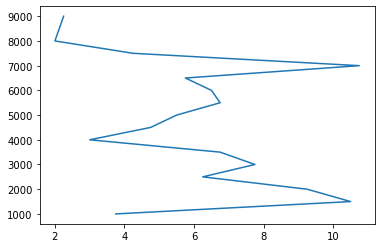

In [54]:
plt.plot(cell_CoreArea_up[:,1], height)

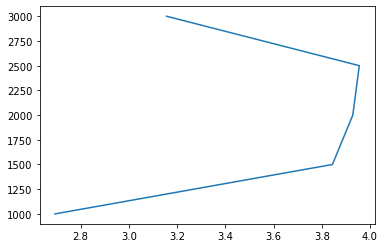

In [58]:
plt.plot(cell_CoreMaxW_up[:,9], height)

In [318]:
iW_np = dsm.WA.where(tracknumber == 175, drop=True).squeeze().data

ncores_min = 10
min_core_npix = 4
z = 1
# Label cores at a given vertical level
core_label, ncores = ndimage.label((iW_np[z,:,:] > W_up_thresh))
# Get core sizes
core_numbers, npix_core = np.unique(core_label, return_counts=True)
# Remove 0 label result since that is the background
npix_core = npix_core[core_numbers > 0]
core_numbers = core_numbers[core_numbers > 0]

# Remove small cores
mask = npix_core > min_core_npix
npix_core = npix_core[mask]
core_numbers = core_numbers[mask]

# Sort the core size by descending order
sort_idx = npix_core.argsort()[::-1]
npix_core_sorted = npix_core[sort_idx]
core_numbers_sorted = core_numbers[sort_idx]
# Save the largest X cores
ncores_save = np.nanmin([ncores, ncores_min])
npix_core_sorted[:ncores_save], core_numbers_sorted[:ncores_save]

(array([52, 15, 11,  9,  8,  8,  7,  6,  5,  5]),
 array([24,  9,  5, 22, 15, 11,  2, 42, 33, 27], dtype=int32))

In [297]:
core_numbers

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59])

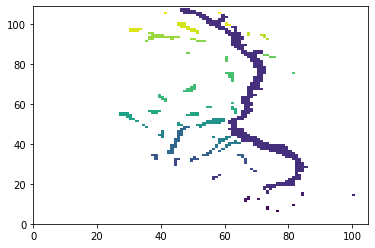

In [293]:
z = 1
Zm = np.ma.masked_where(iW_cores[z,:,:] == 0, iW_cores[z,:,:])
plt.pcolormesh(Zm)

In [231]:
core_numbers, npix_core = np.unique(iW_cores, return_counts=True)
# Remove 0 label result since that is the background
npix_core = npix_core[core_numbers > 0]
core_numbers = core_numbers[core_numbers > 0]

# Sort the core size by descending order
sort_idx = npix_core.argsort()[::-1]
npix_core_sorted = npix_core[sort_idx]
core_numbers_sorted = core_numbers[sort_idx]
npix_core_sorted, core_numbers_sorted

(array([17820,   314,   200,   168,   158,   127,   123,    93,    91,
           80,    78,    64,    57,    56,    53,    49,    46,    45,
           43,    41,    38,    38,    37,    35,    34,    30,    30,
           29,    28,    26,    24,    23,    23,    21,    21,    19,
           17,    17,    16,    15,    15,    14,    14,    14,    13,
           13,    12,    12,    11,    11,    10,    10,     9,     9,
            9,     8,     7,     7,     7,     7,     7,     6,     6,
            6,     6,     6,     5,     5,     5,     5,     4,     4,
            4,     4,     4,     4,     3,     3,     3,     3,     3,
            3,     3,     3,     3,     3,     2,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     2,     2,     2,     2,     2,     2,     2,
            2,     2,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     1,     1,     1,     1,     1,     1,     1,
      

In [232]:
nmax_core = 10
if len(core_numbers_sorted) < nmax_core:
    ncore_save = len(core_numbers_sorted)
else:
    ncore_save = nmax_core
core_numbers_save = core_numbers_sorted[0:ncore_save]
core_numbers_save

array([  8, 180, 102,  98, 184, 149,  38,  91,  93, 165], dtype=int32)

In [233]:
# Loop over each vertical level, then loop over each labeled core, from the largest core number (which is determined in 3D) to the smaller ones
# at each level, simply count the number of grids belonging to the same core, even though they may not be all connected at that level
# they are connected in 3D, so the counts can be approximated as a contiguous core area
# By going from the same core order at each vertical level, the saved core area sorted by total core "volume" (number of grids in 3D) 
# represents contiguous 3D core objects, then the core area/width derived separately at each level essentially represents a contiguous core area profile
core_ngrids = np.full((nz, ncore_save), np.NaN, dtype=float)

for ilev in range(0, len(height)):
    for ic, core_num in enumerate(core_numbers_save):
        # print(height.values[ilev], core_numbers_save[icore])
        iW_lev = iW_cores[ilev,:,:]
        core_ngrids[ilev,ic] = np.count_nonzero(iW_lev == core_num)

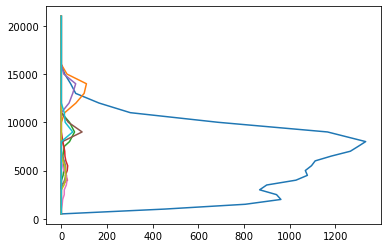

In [234]:
plt.plot(core_ngrids, height)

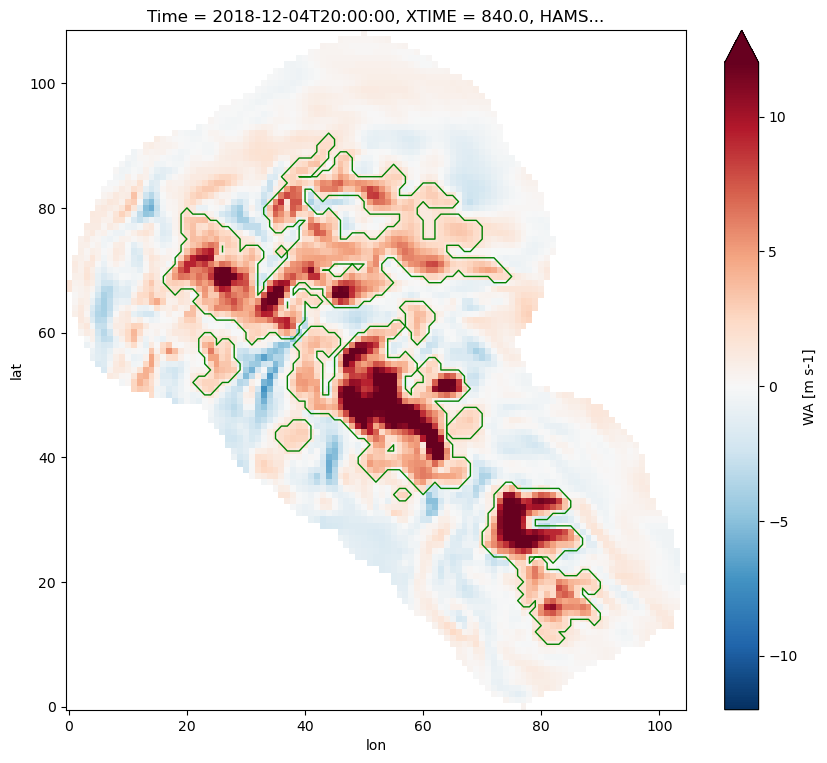

In [254]:
fig = plt.figure(figsize=[10,9], dpi=100)

icorenum = 8

zidx = np.where(height == 8000)[0].item()
imask = iW_cores[zidx,:,:] == icorenum
# print(np.count_nonzero(imask))
Zm = np.ma.masked_invalid(imask)

iW.sel(HAMSL=8000).plot(vmin=-12, vmax=12, cmap='RdBu_r')
plt.contour(Zm, levels=[0,2], colors='g', linewidths=1)
# plt.pcolormesh(Zm)
# np.count_nonzero(iW_cores[zidx,:,:] == 2)

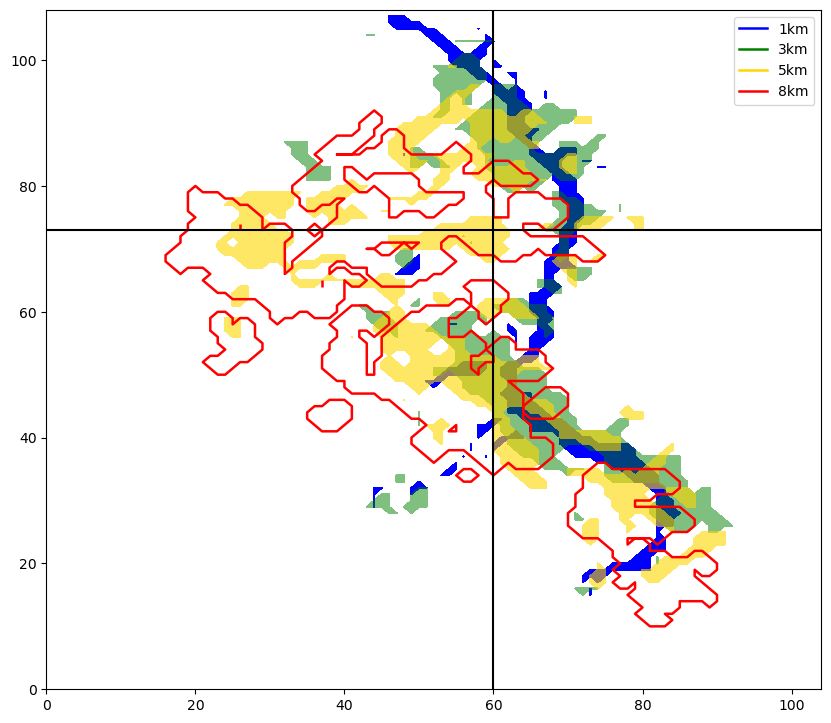

In [274]:
fig = plt.figure(figsize=[10,9], dpi=100)

icorenum = 8

iz = iW.HAMSL.data
imask = iW_cores == icorenum
Zm = np.ma.masked_invalid(imask)

lw = 1.8
ct1 = plt.contourf(Zm[iz==1000,:,:].squeeze(), levels=[0.9,2], colors='b', linewidths=lw)
ct2 = plt.contourf(Zm[iz==3000,:,:].squeeze(), levels=[0.9,2], colors='g', linewidths=lw, alpha=0.5)
ct3 = plt.contourf(Zm[iz==5000,:,:].squeeze(), levels=[0.9,2], colors='gold', linewidths=lw, alpha=0.6)
ct4 = plt.contour(Zm[iz==8000,:,:].squeeze(), levels=[0,10], colors='r', linewidths=lw)

xidx = 60
yidx = 73
plt.axhline(yidx, color='k')
plt.axvline(xidx, color='k')

legend_elements = [
    mpl.lines.Line2D([0], [0], color='b', lw=lw),
    mpl.lines.Line2D([0], [0], color='g', lw=lw),
    mpl.lines.Line2D([0], [0], color='gold', lw=lw),
    mpl.lines.Line2D([0], [0], color='r', lw=lw),
]
plt.legend(legend_elements, ['1km', '3km', '5km', '8km'])

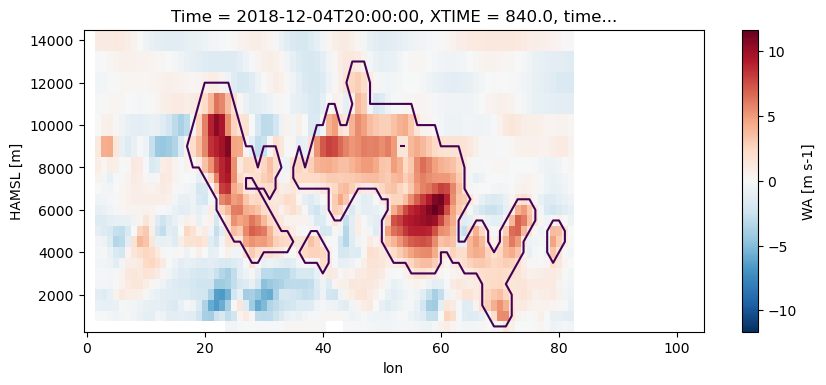

In [244]:
fig = plt.figure(figsize=[10,4], dpi=100)
ix = iW.lon
iz = iW.HAMSL
# plt.pcolormesh(ix, iz, iW.isel(lat=30).sel(HMASL=slice(0,14000)), vmin=-12, vmax=12, cmap='RdBu_r')
# plt.colorbar()
iW.isel(lat=yidx).sel(HAMSL=slice(0,14000)).plot()
icore = iW_cores[:,yidx,:] == icorenum
plt.contour(ix, iz, icore, levels=[0,10])

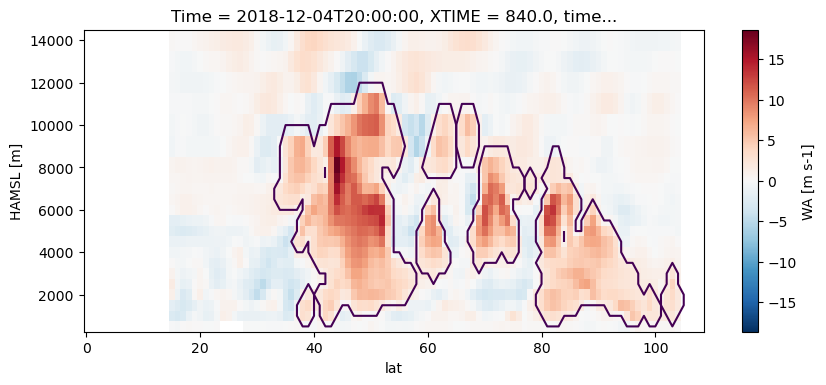

In [241]:
fig = plt.figure(figsize=[10,4], dpi=100)

iy = iW.lat
iz = iW.HAMSL
# plt.pcolormesh(ix, iz, iW.isel(lat=30).sel(HMASL=slice(0,14000)), vmin=-12, vmax=12, cmap='RdBu_r')
# plt.colorbar()
iW.isel(lon=xidx).sel(HAMSL=slice(0,14000)).plot()
icore = iW_cores[:,:,xidx] == icorenum
plt.contour(iy, iz, icore, levels=[0,10])